In [1]:
import os 
import pandas as pd
import matplotlib.pyplot as plt  
from sklearn.cluster import KMeans  
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score

In [2]:
inputsFolder = os.path.join("C:/Career Projects/Credit Card Clustering/Inputs")
outputsFolder = os.path.join("C:/Career Projects/Credit Card Clustering/Outputs")
imagesFolder = os.path.join(outputsFolder, "Images")

# Build the full file path
file_path = os.path.join(inputsFolder, "CC GENERAL.csv")

cc = pd.read_csv(file_path)

print(cc.head())

  CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  C10001    40.900749           0.818182      95.40              0.00   
1  C10002  3202.467416           0.909091       0.00              0.00   
2  C10003  2495.148862           1.000000     773.17            773.17   
3  C10004  1666.670542           0.636364    1499.00           1499.00   
4  C10005   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1                    0.000000       

In [3]:
# Find Total Transactions
cc['TOTAL_TRX'] = cc['PURCHASES_TRX'] + cc['CASH_ADVANCE_TRX']

# We will make a column that calculates how close a User's Balance is to their Credit Limit
cc['BALANCE_LIMIT_RATIO'] = (cc['BALANCE']/cc['CREDIT_LIMIT'])
cc['BALANCE_LIMIT_RATIO']

# Find Average payments per month
cc['AVG_PURCHASES'] = cc['PURCHASES'] / cc['TENURE']
cc['AVG_PURCHASES']

# Create a column that compares the average purchases to the Credit Limit
cc['AVG_PURCHASES_LIMIT_RATIO'] = cc['AVG_PURCHASES']/cc['CREDIT_LIMIT']
cc['AVG_PURCHASES_LIMIT_RATIO'] 

0       0.007950
1       0.000000
2       0.008591
3       0.016656
4       0.001111
          ...   
8945    0.048520
8946    0.050000
8947    0.024067
8948    0.000000
8949    0.151840
Name: AVG_PURCHASES_LIMIT_RATIO, Length: 8950, dtype: float64

In [4]:
# The Purpose of this exercise is to identify which of these Credit Card users are appropriate to apply a Credit Limit increase to.
# We are going to focus on BALANCE_LIMIT_RATIO and AVG_PURCHASE_LIMIT_RATIO to make this determination

creditLimitCriteria = cc[['BALANCE_LIMIT_RATIO', 'AVG_PURCHASES_LIMIT_RATIO']].copy()
creditLimitCriteria.dropna(inplace=True)
# Scale to increase the efficacy of Clustering
scaler = StandardScaler()
scaled_criteria = scaler.fit_transform(creditLimitCriteria)

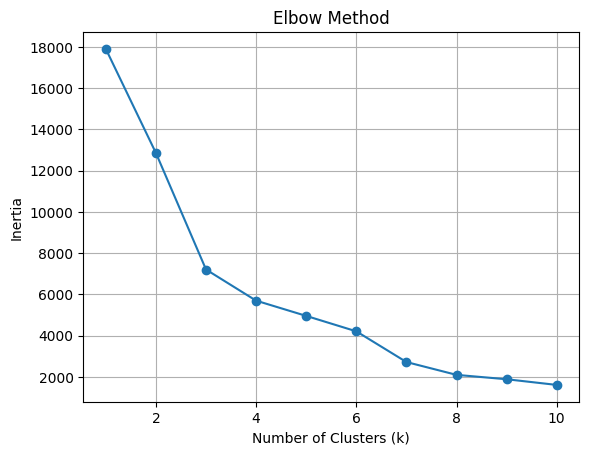

In [5]:
# Elbow Analysis to identify the amount of Clusters needed by the data
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_criteria)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)


plt.savefig(os.path.join(imagesFolder, "elbow.png"), dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# Based on the conclusions from the Elbow Graph, we will need 3 Clusters. As you can see, the graph's inflection
# stagnates around the 3rd Cluster.

k = 3 # Cluster Number
kmeans = KMeans(n_clusters = k, random_state=500)
kmeans.fit(scaled_criteria)

labels = kmeans.labels_ 


clustered_users = pd.DataFrame({
    'CUST_ID': cc.loc[creditLimitCriteria.index, 'CUST_ID'],
    'SEGMENT': labels
})

cc_with_clusters = cc.merge(clustered_users, on='CUST_ID')

In [7]:
cc_with_clusters.groupby('SEGMENT')[['BALANCE_LIMIT_RATIO', 'AVG_PURCHASES_LIMIT_RATIO']].mean()

,BALANCE_LIMIT_RATIO,AVG_PURCHASES_LIMIT_RATIO
SEGMENT,,
0,0.127498,0.016550
1,0.414354,0.124850
2,0.789857,0.012741


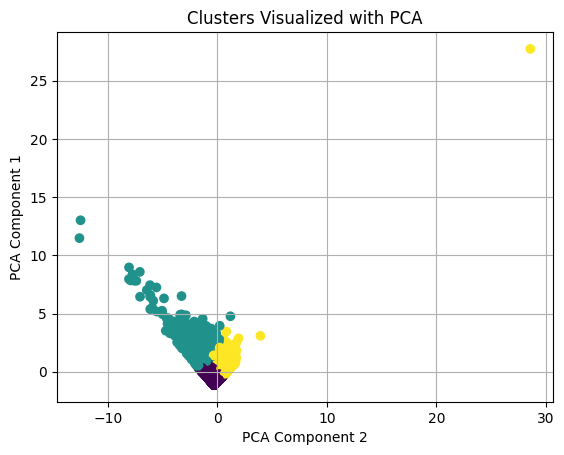

In [8]:
# Visualizing Scaled Clusters
pca = PCA(n_components=2)
reduced = pca.fit_transform(scaled_criteria)

plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap='viridis')
plt.title("Clusters Visualized with PCA")
plt.ylabel("PCA Component 1")
plt.xlabel("PCA Component 2")
plt.grid(True)

plt.savefig(os.path.join(imagesFolder, "pca_graph.png"), dpi=300, bbox_inches='tight')
plt.show()


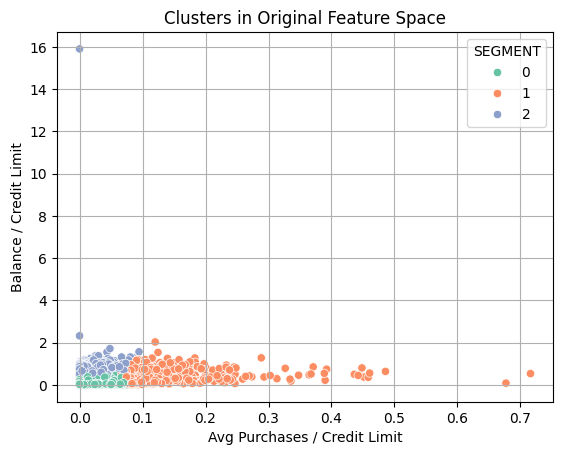

In [9]:
# Visualizing the Clusters with their original values
sns.scatterplot(
    data=cc_with_clusters,
    y='BALANCE_LIMIT_RATIO',
    x='AVG_PURCHASES_LIMIT_RATIO',
    hue='SEGMENT',
    palette='Set2'
)
plt.title('Clusters in Original Feature Space')
plt.ylabel('Balance / Credit Limit')
plt.xlabel('Avg Purchases / Credit Limit')
plt.grid(True)

plt.savefig(os.path.join(imagesFolder, "cluster_graph1.png"), dpi=300, bbox_inches='tight')
plt.show()

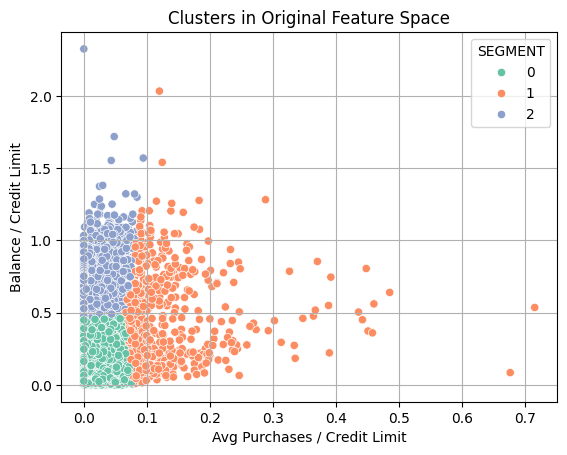

In [10]:
maxId = cc_with_clusters['BALANCE_LIMIT_RATIO'].idxmax()
cc_with_clusters_no_outlier = cc_with_clusters.drop(index=maxId)

cc_with_clusters.to_csv(os.path.join(outputsFolder, "cc_with_clusters_outliers.csv"), index=False)
cc_with_clusters_no_outlier.to_csv(os.path.join(outputsFolder, "cc_with_clusters_no_outlier.csv"), index=False)

# Visualizing the Clusters with their original values
sns.scatterplot(
    data=cc_with_clusters_no_outlier,
    y='BALANCE_LIMIT_RATIO',
    x='AVG_PURCHASES_LIMIT_RATIO',
    hue='SEGMENT',
    palette='Set2'
)
plt.title('Clusters in Original Feature Space')
plt.ylabel('Balance / Credit Limit')
plt.xlabel('Avg Purchases / Credit Limit')
plt.grid(True)

plt.savefig(os.path.join(imagesFolder, "clusters_2.png"), dpi=300, bbox_inches='tight')
plt.show()



In [11]:
# Visually, while the above chart uses the 3 clusters suggested by the elbow method, I see potential for including a 4th cluster which
# divides Segment 1 into two halves. One half for high spenders with lower Utilization, and the other half for high spenders with
# high utilization.

sil_score_3 = silhouette_score(scaled_criteria, KMeans(n_clusters=3, random_state=500).fit_predict(scaled_criteria))
sil_score_4 = silhouette_score(scaled_criteria, KMeans(n_clusters=4, random_state=500).fit_predict(scaled_criteria))
sil_score_5 = silhouette_score(scaled_criteria, KMeans(n_clusters=5, random_state=500).fit_predict(scaled_criteria))
sil_score_6 = silhouette_score(scaled_criteria, KMeans(n_clusters=5, random_state=500).fit_predict(scaled_criteria))
# Silhouette Score gives us a mathematical heuristic on what value could be added by Clusters.
print(f"Silhouette Score (k=3): {sil_score_3:.3f}")
print(f"Silhouette Score (k=4): {sil_score_4:.3f}")
print(f"Silhouette Score (k=5): {sil_score_5:.3f}")
print(f"Silhouette Score (k=6): {sil_score_5:.3f}")

# We are going to Over-Cluster to 6, with the intention of exploring the data and seeing what meaningful groups might appear.

# Rerun KMeans with 6 clusters
kmeans_6 = KMeans(n_clusters=6, random_state=500)
cluster_labels_6 = kmeans_6.fit_predict(scaled_criteria)

# Add the new cluster labels to your DataFrame
cc_with_clusters['SEGMENT_RUN2'] = cluster_labels_6
cc_with_clusters

Silhouette Score (k=3): 0.544
Silhouette Score (k=4): 0.441
Silhouette Score (k=5): 0.472
Silhouette Score (k=6): 0.472


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,...,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,TOTAL_TRX,BALANCE_LIMIT_RATIO,AVG_PURCHASES,AVG_PURCHASES_LIMIT_RATIO,SEGMENT,SEGMENT_RUN2
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,...,201.802084,139.509787,0.000000,12,2,0.040901,7.950000,0.007950,0,3
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,...,4103.032597,1072.340217,0.222222,12,4,0.457495,0.000000,0.000000,2,0
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,...,622.066742,627.284787,0.000000,12,12,0.332687,64.430833,0.008591,0,0
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,...,0.000000,NaN,0.000000,12,2,0.222223,124.916667,0.016656,0,3
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,...,678.334763,244.791237,0.000000,12,1,0.681429,1.333333,0.001111,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8944,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,...,325.594462,48.886365,0.500000,6,6,0.028494,48.520000,0.048520,0,1
8945,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,...,275.861322,NaN,0.000000,6,6,0.019183,50.000000,0.050000,0,1
8946,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,...,81.270775,82.418369,0.250000,6,5,0.023399,24.066667,0.024067,0,3
8947,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,...,52.549959,55.755628,0.250000,6,2,0.026915,0.000000,0.000000,0,3


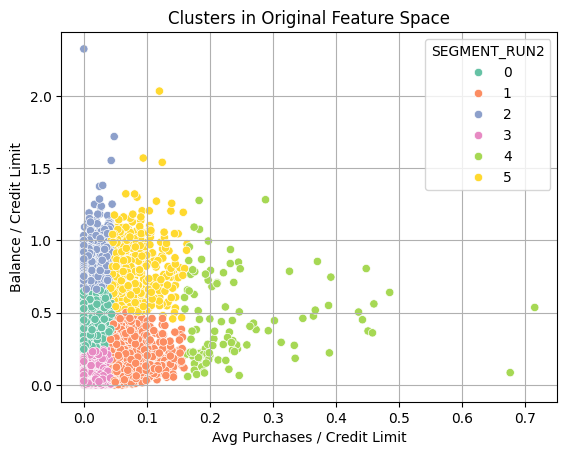

In [12]:
maxId = cc_with_clusters['BALANCE_LIMIT_RATIO'].idxmax()
cc_with_clusters_no_outlier = cc_with_clusters.drop(index=maxId)

# Visualizing the Clusters with their original values
sns.scatterplot(
    data=cc_with_clusters_no_outlier,
    y='BALANCE_LIMIT_RATIO',
    x='AVG_PURCHASES_LIMIT_RATIO',
    hue='SEGMENT_RUN2',
    palette='Set2'
)
plt.title('Clusters in Original Feature Space')
plt.ylabel('Balance / Credit Limit')
plt.xlabel('Avg Purchases / Credit Limit')
plt.grid(True)

plt.savefig(os.path.join(imagesFolder, "clusters_3_overcluster.png"), dpi=300, bbox_inches='tight')
plt.show()

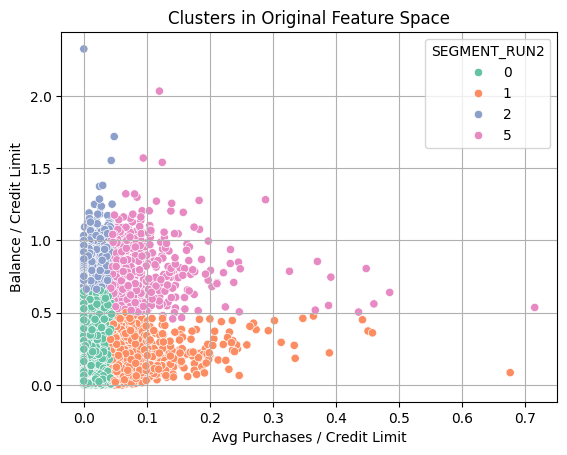

In [13]:
# Now that we have applied additional clusters, we can consolidate them based on a visual analysis.
cc_with_clusters_no_outlier.loc[cc_with_clusters_no_outlier['SEGMENT_RUN2'] == 3, 'SEGMENT_RUN2'] = 0

# I want to consolidate half of Cluster 4 into Cluster 1, and the other half into cluster 5. I want to base the separation on whether
# the cluster exceeds a 30% utilization rate which is roughly considered as good in the Credit industry.

cc_with_clusters_no_outlier.loc[
    (cc_with_clusters_no_outlier['SEGMENT_RUN2'] == 4) &
    (cc_with_clusters_no_outlier['BALANCE_LIMIT_RATIO'] > 0.49),
    'SEGMENT_RUN2'
] = 5

cc_with_clusters_no_outlier.loc[
    (cc_with_clusters_no_outlier['SEGMENT_RUN2'] == 4) &
    (cc_with_clusters_no_outlier['BALANCE_LIMIT_RATIO'] <= 0.49),
    'SEGMENT_RUN2'
] = 1

# Visualizing the Clusters with their original values
sns.scatterplot(
    data=cc_with_clusters_no_outlier,
    y='BALANCE_LIMIT_RATIO',
    x='AVG_PURCHASES_LIMIT_RATIO',
    hue='SEGMENT_RUN2',
    palette='Set2'
)
plt.title('Clusters in Original Feature Space')
plt.ylabel('Balance / Credit Limit')
plt.xlabel('Avg Purchases / Credit Limit')
plt.grid(True)

plt.savefig(os.path.join(imagesFolder, "clusters_4_consolidated.png"), dpi=300, bbox_inches='tight')
plt.show()

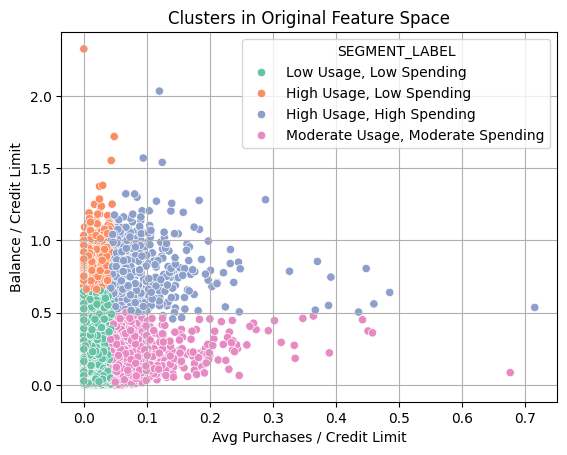

In [14]:
label_map = {
    0: 'Low Usage, Low Spending',
    1: 'Moderate Usage, Moderate Spending',
    2: 'High Usage, Low Spending',
    5: 'High Usage, High Spending'
}

cc_with_clusters_no_outlier['SEGMENT_LABEL'] = cc_with_clusters_no_outlier['SEGMENT_RUN2'].map(label_map)
cc_with_clusters_no_outlier.to_csv(os.path.join(outputsFolder, "cc_with_clusters_final.csv"), index=False)

sns.scatterplot(
    data=cc_with_clusters_no_outlier,
    y='BALANCE_LIMIT_RATIO',
    x='AVG_PURCHASES_LIMIT_RATIO',
    hue='SEGMENT_LABEL',
    palette='Set2'
)
plt.title('Clusters in Original Feature Space')
plt.ylabel('Balance / Credit Limit')
plt.xlabel('Avg Purchases / Credit Limit')
plt.grid(True)

plt.savefig(os.path.join(imagesFolder, "clusters_final.png"), dpi=300, bbox_inches='tight')
plt.show()


In [15]:
# The conclusion we can draw from this excercise is that the group we have identified as Moderate Usage, Moderate Spending
# is the ideal group to apply a credit increase to. This group uses their frequently Credit Card, but also spends on it responsibly.
